In [4]:
files = []
for y in range(16, 17):
    for m in range(1, 13):
        for d in range(1, 32):
            if m<10 and d<10:
                fp = 'Eventi/Muoni_Orario_20{}_0{}_0{}.txt'.format(y, m, d)
            elif m<10 and d>=10:
                fp = 'Eventi/Muoni_Orario_20{}_0{}_{}.txt'.format(y, m, d)
            elif m>=10 and d<10:
                fp = 'Eventi/Muoni_Orario_20{}_{}_0{}.txt'.format(y, m, d)
            elif m>=10 and d>=10:
                fp = 'Eventi/Muoni_Orario_20{}_{}_{}.txt'.format(y, m, d)
            files.append(fp)

In [6]:
import pandas as pd
import numpy as np
from datetime import time, timedelta
import matplotlib.pyplot as plt

In [7]:
durations = []
for file in files:
    try:
        temp = pd.read_table(file, sep = r'\s+', names = ['event_id','time','theta_x','theta_y'])
        time = pd.to_timedelta(temp.time)
        timemin, timemax = time.min(), time.max()
        deltatime = timemax - timemin
        durations.append(deltatime)
    except:
        None
durations

[Timedelta('0 days 10:23:15'),
 Timedelta('0 days 23:56:49'),
 Timedelta('0 days 23:58:22'),
 Timedelta('0 days 23:58:22'),
 Timedelta('0 days 23:59:38'),
 Timedelta('0 days 13:05:20'),
 Timedelta('0 days 12:03:13'),
 Timedelta('0 days 23:58:31'),
 Timedelta('0 days 23:58:29'),
 Timedelta('0 days 23:58:32'),
 Timedelta('0 days 23:57:06'),
 Timedelta('0 days 23:58:10'),
 Timedelta('0 days 23:57:40'),
 Timedelta('0 days 23:59:24'),
 Timedelta('0 days 23:56:27'),
 Timedelta('0 days 21:06:16'),
 Timedelta('0 days 12:57:30'),
 Timedelta('0 days 23:58:53'),
 Timedelta('0 days 23:57:48'),
 Timedelta('0 days 23:59:20'),
 Timedelta('0 days 23:58:34'),
 Timedelta('0 days 23:58:12'),
 Timedelta('0 days 23:58:47'),
 Timedelta('0 days 09:45:13'),
 Timedelta('0 days 13:43:18'),
 Timedelta('0 days 23:58:02'),
 Timedelta('0 days 23:59:02'),
 Timedelta('0 days 23:59:32'),
 Timedelta('0 days 23:59:47'),
 Timedelta('0 days 23:58:48'),
 Timedelta('0 days 23:59:29'),
 Timedelta('0 days 23:56:21'),
 Timedel

In [8]:
test = files[310]
df = pd.read_table(test, sep = r'\s+', names = ['event_id','time','theta_x','theta_y'])
df['datetime'] = pd.to_datetime(df.time, format='%H:%M:%S')
df

,event_id,time,theta_x,theta_y,datetime
0,ST1A04,00:00:49,-5.56,2.80,1900-01-01 00:00:49
1,ST1A05,00:02:39,-1.24,-1.17,1900-01-01 00:02:39
2,ST1A06,00:03:07,-35.54,-20.59,1900-01-01 00:03:07
3,ST1A07,00:03:35,5.44,0.00,1900-01-01 00:03:35
4,ST1A08,00:04:46,-19.66,-1.33,1900-01-01 00:04:46
...,...,...,...,...,...
1910,ST217A,23:56:58,39.78,-29.75,1900-01-01 23:56:58
1911,ST217B,23:57:24,3.30,13.44,1900-01-01 23:57:24
1912,ST217C,23:57:50,4.66,-3.28,1900-01-01 23:57:50
1913,ST217D,23:58:57,0.54,30.35,1900-01-01 23:58:57


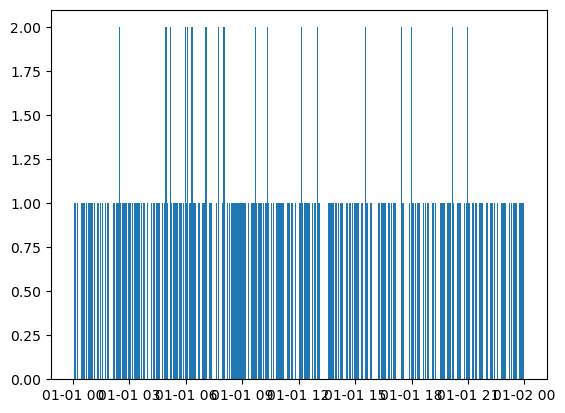

In [9]:
n,e,_ = plt.hist(df.datetime, bins=2880)

In [13]:
df['timedelta'] = pd.to_timedelta(df.time)
df

,event_id,time,theta_x,theta_y,datetime,timedelta
0,ST1A04,00:00:49,-5.56,2.80,1900-01-01 00:00:49,0 days 00:00:49
1,ST1A05,00:02:39,-1.24,-1.17,1900-01-01 00:02:39,0 days 00:02:39
2,ST1A06,00:03:07,-35.54,-20.59,1900-01-01 00:03:07,0 days 00:03:07
3,ST1A07,00:03:35,5.44,0.00,1900-01-01 00:03:35,0 days 00:03:35
4,ST1A08,00:04:46,-19.66,-1.33,1900-01-01 00:04:46,0 days 00:04:46
...,...,...,...,...,...,...
1910,ST217A,23:56:58,39.78,-29.75,1900-01-01 23:56:58,0 days 23:56:58
1911,ST217B,23:57:24,3.30,13.44,1900-01-01 23:57:24,0 days 23:57:24
1912,ST217C,23:57:50,4.66,-3.28,1900-01-01 23:57:50,0 days 23:57:50
1913,ST217D,23:58:57,0.54,30.35,1900-01-01 23:58:57,0 days 23:58:57


In [14]:
dt = (df.timedelta.values[1:] - df.timedelta.values[:-1])

In [29]:
t_tot = timedelta()
for file in files:
    try:
        temp = pd.read_table(file, sep = r'\s+', names = ['event_id','time','theta_x','theta_y'])
        time = pd.to_timedelta(temp.time).values
        for i in range(len(time)):
            t1, t2 = time[i], time[i+1]
            delta = t2 - t1
            dt = timedelta(minutes = 1)
            if delta>dt:
                t_tot+=delta
    except:
        None
t_tot

0

In [89]:
t_tot = round(pd.Series(durations).sum().total_seconds()/60, 0)
t_tot

104372.0

In [91]:
l = 0.4
n = 10
s_tot = n*l**2
r = 1e4
I0 = r*s_tot*t_tot
I0

1669952000.0000005

In [ ]:
help(timedelta)